# optuna

[optuna](https://optuna.readthedocs.io/) is a highly advanced hyperparameter tuning framework that goes beyond Scikit-Learn's grid and random search. Let's take a look at how we can use optuna to tune a model.

## Load data

We will use the diabetes data.

In [1]:
from sklearn.datasets import load_diabetes

X, y = load_diabetes(return_X_y=True, as_frame=True)
X.shape, y.shape

((442, 10), (442,))

In [2]:
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.10, random_state=37)

X_tr.shape, X_te.shape, y_tr.shape, y_te.shape

((397, 10), (45, 10), (397,), (45,))

## Tuning

Now, the tuning begins. Optuna requires an `objective` function that takes in a [trial](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html#optuna.trial.Trial) object and returns a scalar or tuple; when a tuple of scalar values is returned, the tuning is called multiobjective tuning. In this example, we have only one objective which is to minimize the mean absolute erorr `MAE`.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import numpy as np
import optuna

from _runtime import SCIKIT_INTRO_CHECK_MODE

np.random.seed(37)
optuna.logging.set_verbosity(optuna.logging.WARNING)

def get_model(imputer_params={}, regressor_params={}):
    model = Pipeline([
        ('imputer', SimpleImputer(**imputer_params)),
        ('regressor', RandomForestRegressor(**regressor_params))
    ])
    
    return model

def objective(trial):
    i_params = {
        'strategy': trial.suggest_categorical('strategy', ['mean', 'median', 'most_frequent'])
    }
    
    r_params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 200),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'criterion': trial.suggest_categorical('criterion', ['squared_error', 'absolute_error', 'poisson']),
        'max_features': trial.suggest_categorical('max_features', [1.0, 'sqrt', 'log2']),
        'bootstrap': False,
        'oob_score': False,
        'warm_start': trial.suggest_categorical('warm_start', [True, False]),
        'ccp_alpha': trial.suggest_float('ccp_alpha', 0, 1),
        'max_depth': trial.suggest_int('max_depth', 1, 100),
        'random_state': 37
    }
    
    model = get_model(i_params, r_params)
    model.fit(X_tr, y_tr)
    
    y_pred = model.predict(X_te)
    
    mae = mean_absolute_error(y_te, y_pred)
    rmse = root_mean_squared_error(y_te, y_pred)
    r2s = r2_score(y_te, y_pred)
    
    trial.set_user_attr('mae', mae)
    trial.set_user_attr('rmse', rmse)
    trial.set_user_attr('r2s', r2s)
    
    return mae

After we create an objective function, we can create a [study](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.study.Study.html#optuna.study.Study) and perform optimization.

In [5]:
study = optuna.create_study(**{
    'study_name': 'optuna-rf-study',
    'storage': 'sqlite:///_temp/optuna-rf-study.db',
    'load_if_exists': True,
    'direction': 'minimize',
    'sampler': optuna.samplers.TPESampler(seed=37),
    'pruner': optuna.pruners.MedianPruner(n_warmup_steps=10)
})

study.optimize(**{
    'func': objective, 
    'n_trials': 5 if SCIKIT_INTRO_CHECK_MODE else 100,
    'n_jobs': 1,
    'show_progress_bar': False
})

Now we may look at the best hyperparameters, value (the value we are trying to optmize for), and trial.

In [6]:
study.best_params

{'ccp_alpha': 0.6016097921882426,
 'criterion': 'absolute_error',
 'max_depth': 6,
 'max_features': 'auto',
 'min_samples_leaf': 2,
 'min_samples_split': 9,
 'n_estimators': 193,
 'strategy': 'most_frequent',
 'warm_start': False}

In [7]:
study.best_value

40.65555555555556

In [8]:
study.best_trial

FrozenTrial(number=62, values=[40.65555555555556], datetime_start=datetime.datetime(2023, 6, 1, 22, 34, 59, 583419), datetime_complete=datetime.datetime(2023, 6, 1, 22, 35, 1, 525495), params={'ccp_alpha': 0.6016097921882426, 'criterion': 'absolute_error', 'max_depth': 6, 'max_features': 'auto', 'min_samples_leaf': 2, 'min_samples_split': 9, 'n_estimators': 193, 'strategy': 'most_frequent', 'warm_start': False}, distributions={'ccp_alpha': FloatDistribution(high=1.0, log=False, low=0.0, step=None), 'criterion': CategoricalDistribution(choices=('squared_error', 'absolute_error', 'poisson')), 'max_depth': IntDistribution(high=100, log=False, low=1, step=1), 'max_features': CategoricalDistribution(choices=('auto', 'sqrt', 'log2')), 'min_samples_leaf': IntDistribution(high=10, log=False, low=1, step=1), 'min_samples_split': IntDistribution(high=10, log=False, low=2, step=1), 'n_estimators': IntDistribution(high=200, log=False, low=100, step=1), 'strategy': CategoricalDistribution(choices=(

The trial outputs may be retrieved from the study's `trials_dataframe()` method.

In [9]:
study.trials_dataframe().dtypes

number                                int64
value                               float64
datetime_start               datetime64[ns]
datetime_complete            datetime64[ns]
duration                    timedelta64[ns]
params_ccp_alpha                    float64
params_criterion                     object
params_max_depth                      int64
params_max_features                  object
params_min_samples_leaf               int64
params_min_samples_split              int64
params_n_estimators                   int64
params_strategy                      object
params_warm_start                      bool
user_attrs_mae                      float64
user_attrs_r2s                      float64
user_attrs_rmse                     float64
state                                object
dtype: object

In [10]:
study.trials_dataframe()[['number', 'params_criterion', 'params_min_samples_leaf', 'value', 'user_attrs_rmse', 'user_attrs_r2s']] \
    .sort_values(['value', 'user_attrs_rmse', 'user_attrs_r2s']) \
    .head()

,number,params_criterion,params_min_samples_leaf,value,user_attrs_rmse,user_attrs_r2s
62,62,absolute_error,2,40.655556,53.933241,0.585919
92,92,absolute_error,1,40.655556,53.933241,0.585919
52,52,absolute_error,2,41.144444,54.060820,0.583957
53,53,absolute_error,2,41.144444,54.060820,0.583957
54,54,absolute_error,3,41.144444,54.060820,0.583957


We can continue the hyperparameter tuning at a later time.

In [11]:
_study = optuna.create_study(**{
    'study_name': 'optuna-rf-study',
    'storage': 'sqlite:///_temp/optuna-rf-study.db',
    'load_if_exists': True,
    'direction': 'minimize',
    'sampler': optuna.samplers.TPESampler(seed=37),
    'pruner': optuna.pruners.MedianPruner(n_warmup_steps=10)
})

_study.optimize(**{
    'func': objective, 
    'n_trials': 3 if SCIKIT_INTRO_CHECK_MODE else 10,
    'n_jobs': 1 if SCIKIT_INTRO_CHECK_MODE else 5,
    'show_progress_bar': False
})

## Plotting

There are several plots you may use to understand the hyperparameter optmization results.

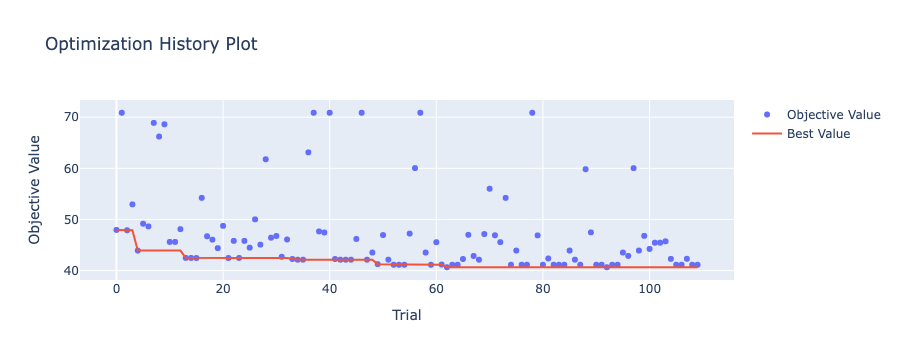

In [13]:
from optuna.visualization import plot_optimization_history

try:
    plot_optimization_history(**{
        'study': _study
    })
except ImportError:
    print('plotly is not installed; skipping Optuna optimization history plot')

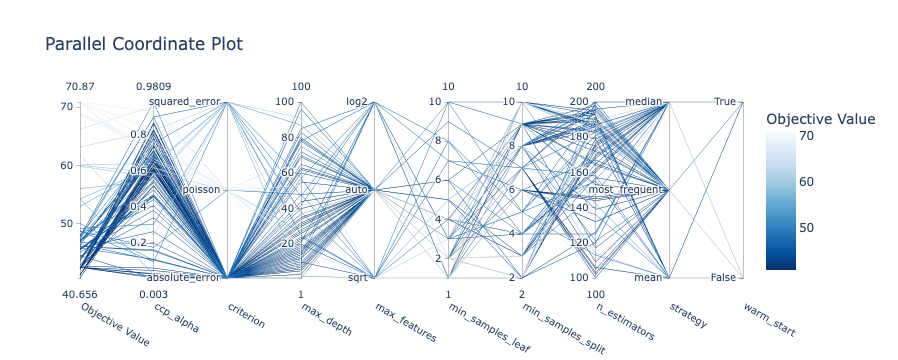

In [14]:
from optuna.visualization import plot_parallel_coordinate

try:
    plot_parallel_coordinate(**{
        'study': _study
    })
except ImportError:
    print('plotly is not installed; skipping Optuna parallel coordinate plot')

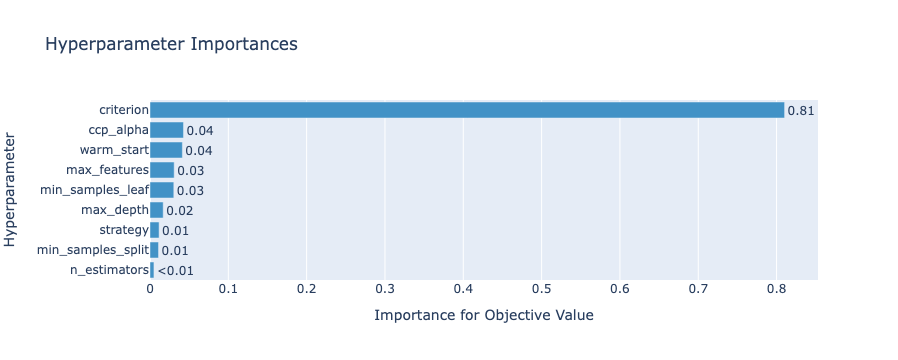

In [15]:
from optuna.visualization import plot_param_importances

try:
    plot_param_importances(**{
        'study': _study
    })
except ImportError:
    print('plotly is not installed; skipping Optuna parameter importance plot')

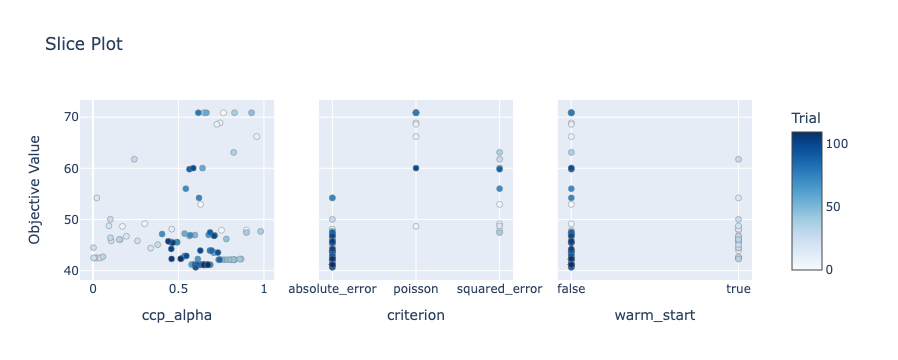

In [16]:
from optuna.visualization import plot_slice

try:
    plot_slice(**{
        'study': _study,
        'params': ['criterion', 'ccp_alpha', 'warm_start']
    })
except ImportError:
    print('plotly is not installed; skipping Optuna slice plot')

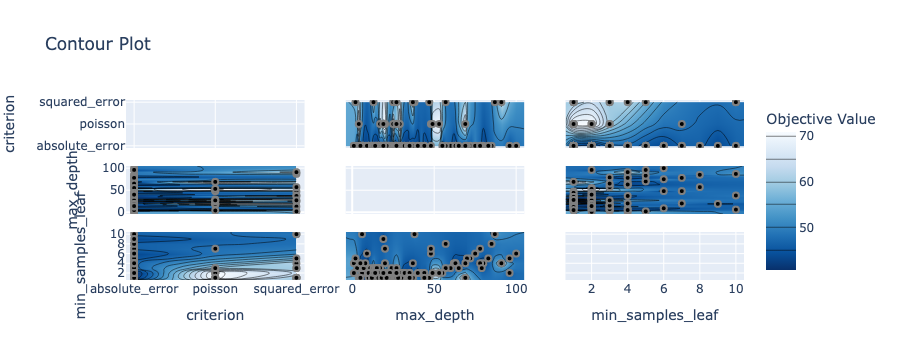

In [17]:
from optuna.visualization import plot_contour

try:
    plot_contour(**{
        'study': _study,
        'params': ['criterion', 'min_samples_leaf', 'max_depth']
    })
except ImportError:
    print('plotly is not installed; skipping Optuna contour plot')

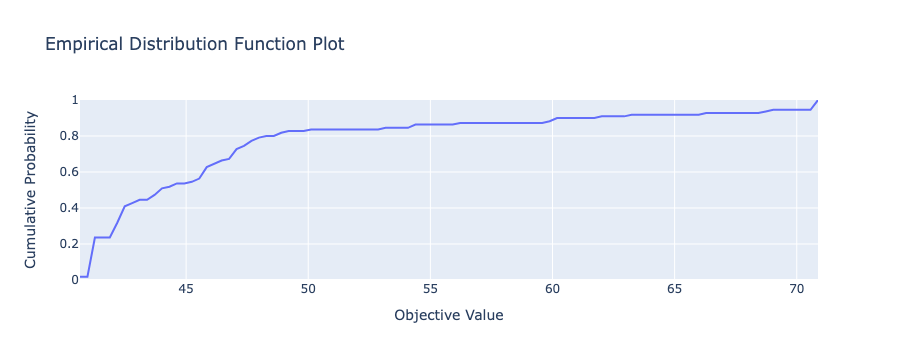

In [18]:
from optuna.visualization import plot_edf

try:
    plot_edf(_study)
except ImportError:
    print('plotly is not installed; skipping Optuna EDF plot')